<a href="https://colab.research.google.com/github/s26673/POSI_MON1/blob/main/EWD_11_cwiczenia_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Praca na zajęciach / domowa
W pliku boston.csv znajdują się dane dotyczące mieszkań w Bostonie:
- crim: per capita crime rate by town.
- zn: proportion of residential land zoned for lots over 25,000 sq.ft.
- indus: proportion of non-retail business acres per town.
- chas: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
- nox: nitrogen oxides concentration (parts per 10 million).
- rm: average number of rooms per dwelling.
- age: proportion of owner-occupied units built prior to 1940.
- dis: weighted mean of distances to five Boston employment centres.
- rad: index of accessibility to radial highways.
- tax: full-value property-tax rate per $10,000.
- ptratio: pupil-teacher ratio by town.
- lstat: lower status of the population (percent).
- medv: median value of owner-occupied homes in $1000s. (**atrybut decyzyjny**)


Boston Housing Dataset. Każda z tych nazw to kolumna w danych:

tax – stawka podatku od nieruchomości (na 10 000 USD wartości)
ptratio – stosunek liczby uczniów do nauczycieli w danym mieście (im wyższy, tym więcej uczniów przypada na jednego nauczyciela)
lstat – procent populacji o niższym statusie społecznym
medv – median value – mediana wartości domów zajmowanych przez właścicieli (w tysiącach dolarów)

👉 To dopisek „atrybut decyzyjny” oznacza, że:

medv jest zmienną, którą próbujesz przewidzieć (czyli target w modelu),
a pozostałe (tax, ptratio, lstat) są zmiennymi wejściowymi (features).

#### Dokonaj analizy danych i przygotuj je do modelowania
1. Zidentyfikuj atrybuty numeryczne i kategoryczne
2. Zidentyfikuj atrybuty w większości unikalne
3. Zidentyfikuj wartości odstające
4. Zidentyfikuj wartości brakujące
5. Zadecyduj, co zrobić z atrybutami z brakującymi / odstającymi wartościami
6. Pozbądź się kolumn z wartościami unikalnymi
7. Zakoduj zmienne kategoryczne
8. Zbadaj korelację między zmiennymi i pozbądź się jednego z pary atrybutów mocno skorelowanych
9. Zastosuj funkcję logarytmiczną i sigmoidalną na wybranych atrybutach numerycznych.
10. Podziel dane na zbiór treningowy, testowy i walidacyjny.

In [2]:
#import bibliotek
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Saving boston.csv to boston.csv


In [3]:
#wczytanie danych i podgląd pliku
file_path = "boston.csv"
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [4]:
#wyświetlenie typów danych dla każdej kolumny
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  lstat       506 non-null    float64
 13  medv        506 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 55.5 KB


None

4. Zidentyfikuj wartości brakujące


In [5]:
#czy są brakujące dane
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
display(pd.DataFrame({"Braki": missing, "Procent [%]": missing_pct}))

,Braki,Procent [%]
Unnamed: 0,0,0.0
crim,0,0.0
zn,0,0.0
indus,0,0.0
chas,0,0.0
nox,0,0.0
rm,0,0.0
age,0,0.0
dis,0,0.0
rad,0,0.0


In [6]:
# czy są jakieś duplikaty?
dupes = df.duplicated().sum()
print("Liczba zduplikowanych wierszy:", dupes)

Liczba zduplikowanych wierszy: 0


1.Zidentyfikuj atrybuty numeryczne i kategoryczne

In [7]:
# automatyczne wykrycie typów
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeryczne:", numeric_cols)
print("Kategoryczne:", categorical_cols)

Numeryczne: ['Unnamed: 0', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat', 'medv']
Kategoryczne: []


In [8]:
df['chas'] = df['chas'].astype('category')
categorical_cols = ['chas']

In [9]:
# Lista kolumn numerycznych (bez kolumn kategorycznych)
numeric_cols = ["crim", "zn", "indus", "nox", "rm", "age",
                "dis", "rad", "tax", "ptratio", "b", "lstat", "medv"]

*   kolumny zostały poprawnie określone typem danych
*   nie ma brakujacych danych
*   nie ma duplikatów

---



2.Zidentyfikuj atrybuty w większości unikalne

In [10]:
unique_ratio = df.nunique() / len(df)

unique_cols = unique_ratio[unique_ratio > 0.95]
print("Kolumny prawie unikalne:")
print(unique_cols)

# unnamed - prawie na pewno indeks
# prawie każda wartość inna (ciągła zmienna), crim -> ~99.6% unikalne

Kolumny prawie unikalne:
Unnamed: 0    1.000000
crim          0.996047
dtype: float64


In [11]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
# usuwa kolumnę Unnamed: 0, errors='ignore' -> jeśli kolumny nie ma, to nie będzie błedu w kodzie

The Boston Housing Dataset

The Boston Housing Dataset is a derived from information collected by the U.S. Census Service concerning housing in the area of Boston MA. The following describes the dataset columns:

* CRIM - per capita crime rate by town
* ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
* INDUS - proportion of non-retail business acres per town.
* CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX - nitric oxides concentration (parts per 10 million)
* RM - average number of rooms per dwelling
* AGE - proportion of owner-occupied units built prior to 1940
* TAX - full-value property-tax rate per (10,000 dollarsów)
* PTRATIO - pupil-teacher ratio by town
* B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
* LSTAT - % lower status of the population
* MEDV - Median value of owner-occupied homes in $1000's

In [12]:
#podstawowe statystyki
df.describe().T

,count,mean,std,min,25%,50%,75%,max
crim,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
zn,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
indus,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
nox,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
rm,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
age,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
dis,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
rad,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
tax,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000
ptratio,506.0,18.455534,2.164946,12.60000,17.400000,19.05000,20.200000,22.0000


3. Zidentyfikuj wartości odstające


In [13]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
#select_dtypes(...) -> wybiera kolumny po typie danych
# int64, float64 -> liczby całkowite i zmiennoprzecinkowe
# .columns -> zwraca tylko nazwy kolumn

In [14]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
#teraz numeric_df zawiera tylko dane numeryczne

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Q1 (25%) -> wartość poniżej której jest 25% danych
# Q3 (75%) -> wartość poniżej której jest 75% danych

outliers = ((numeric_df < (Q1 - 1.5 * IQR)) |
            (numeric_df > (Q3 + 1.5 * IQR))).sum()

print("Liczba wartości odstających:")
print(outliers.sort_values(ascending=False))
# < (Q1 - 1.5 * IQR) -> za małe wartości
# > (Q3 + 1.5 * IQR) -> za duże wartości


Liczba wartości odstających:
zn         68
crim       66
medv       40
rm         30
ptratio    15
lstat       7
dis         5
indus       0
nox         0
age         0
rad         0
tax         0
dtype: int64


In [16]:
for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1

    #iteracja po każdej kolumnie
    # granice policzone osobno dla każdej kolumny(każda kolumna ma inny rozkład)

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)
    #ucięcie skrajności

In [ ]:
# wykresy

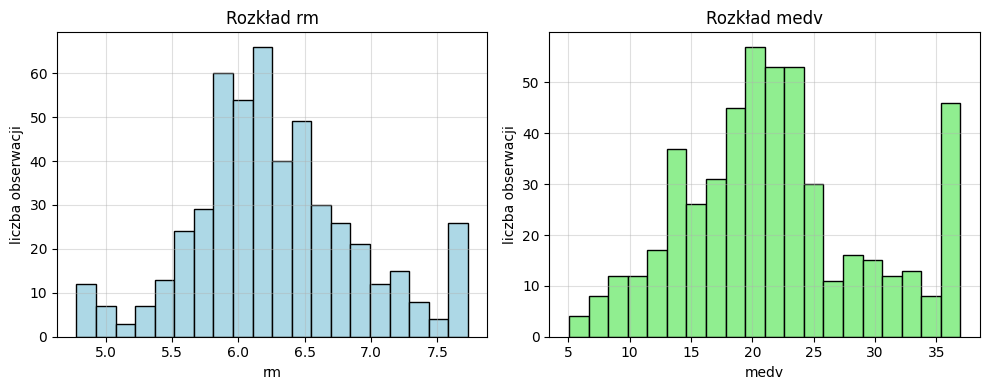

In [17]:
# chcę zobaczyć rozkład (distribution) dwóch zmiennych: rm i medv
plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
plt.hist(df['rm'], bins=20, color='lightblue', edgecolor='black')
plt.title('Rozkład rm')
plt.xlabel('rm')
plt.ylabel('liczba obserwacji')
plt.grid(alpha=0.4)

plt.subplot(1, 2, 2)
plt.hist(df['medv'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Rozkład medv')
plt.xlabel('medv')
plt.ylabel('liczba obserwacji')
plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

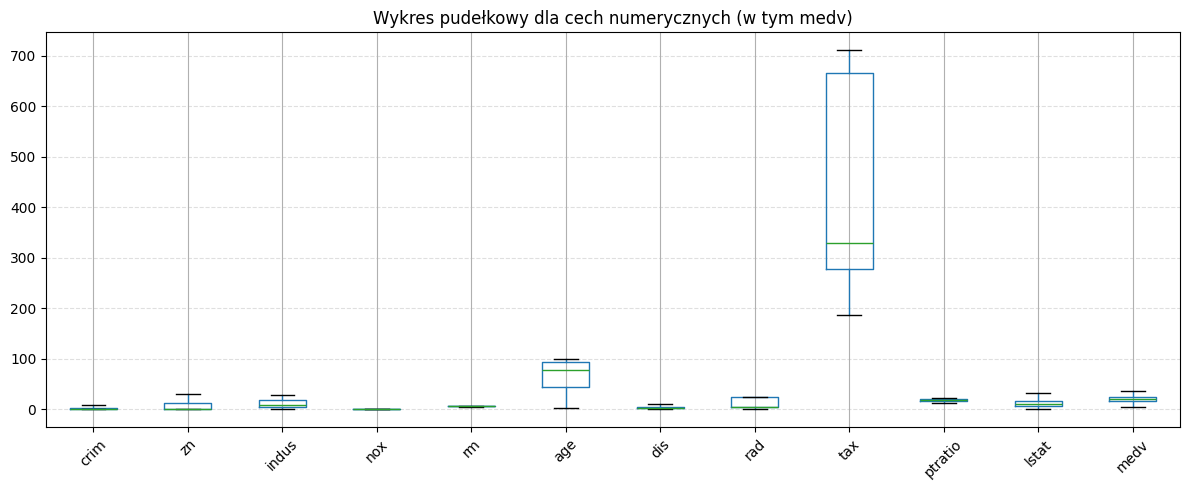

===== IQR — potencjalne outliery =====
      crim:    0 poza zakresem -5.31 – 9.07
        zn:    0 poza zakresem -18.75 – 31.25
     indus:    0 poza zakresem -14.18 – 37.47
       nox:    0 poza zakresem 0.19 – 0.89
        rm:    0 poza zakresem 4.78 – 7.73
       age:    0 poza zakresem -28.55 – 167.65
       dis:    0 poza zakresem -2.53 – 9.82
       rad:    0 poza zakresem -26.00 – 54.00
       tax:    0 poza zakresem -301.50 – 1246.50
   ptratio:    0 poza zakresem 13.20 – 24.40
     lstat:    0 poza zakresem -8.06 – 31.96
      medv:    0 poza zakresem 5.06 – 36.96


In [20]:
# Proste boxploty wybranych kolumn
# cel: szybkie wykrycie:które kolumny mają dużo outlierów, które mają szeroki rozrzut, czy rozkład jest symetryczny

plt.figure(figsize=(12,5))

cols_for_box = df.select_dtypes(include=['int64', 'float64']).columns

df[cols_for_box].boxplot(rot=45)  # 👈 TO BYŁO POTRZEBNE

plt.title("Wykres pudełkowy dla cech numerycznych (w tym medv)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

def detect_outliers_iqr(series: pd.Series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    mask = (series < low) | (series > high)
    return mask.sum(), (low, high)

print("===== IQR — potencjalne outliery =====")
for col in cols_for_box:
    n_out, bounds = detect_outliers_iqr(df[col])
    print(f"{col:>10s}: {n_out:4d} poza zakresem {bounds[0]:.2f} – {bounds[1]:.2f}")


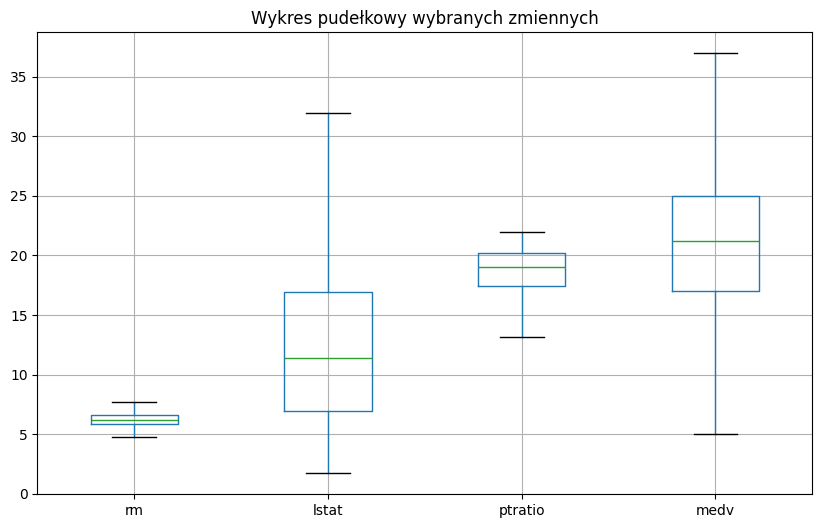

In [21]:
plt.figure(figsize=(10,6))
df.boxplot(column=['rm', 'lstat', 'ptratio', 'medv'])
plt.title("Wykres pudełkowy wybranych zmiennych")
plt.show()

6. Pozbądź się kolumn z wartościami unikalnymi


In [22]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

7. Zakoduj zmienne kategoryczne


In [23]:
df = pd.get_dummies(df, drop_first=True)
# one-hot encoding

##Korelacja (macierz + heatmapa)

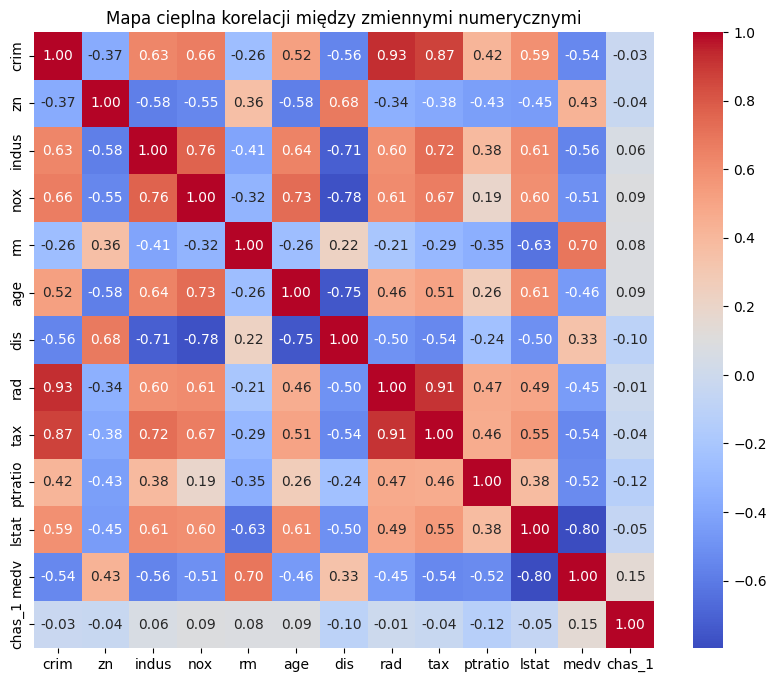

Korelacje względem medv:


,medv
medv,1.00
rm,0.70
zn,0.43
dis,0.33
chas_1,0.15
rad,-0.45
age,-0.46
nox,-0.51
ptratio,-0.52
crim,-0.54


In [24]:
# sprawdzenie zależności między zmiennymi, czyli: co wpływa na medv, które zmienne są podobne do siebie, czy są problemy (np. silne korelacje)
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Mapa cieplna korelacji między zmiennymi numerycznymi")
plt.show()

print("Korelacje względem medv:")
display(corr['medv'].sort_values(ascending=False).round(2))

In [25]:
# Lista kolumn numerycznych (bez kolumn kategorycznych)
numeric_cols = ["crim", "zn", "indus", "nox", "rm", "age",
                "dis", "rad", "tax", "ptratio", "lstat", "medv"]

# Macierz korelacji Pearsona
correlation_matrix = df[numeric_cols].corr(method='pearson')

# Korelacja każdej zmiennej z wartością domów (medv)
correlation_with_medv = correlation_matrix['medv'].sort_values(ascending=False)

print("Korelacja z cechą docelową (medv):\n")
print(correlation_with_medv)

Korelacja z cechą docelową (medv):

medv       1.000000
rm         0.697645
zn         0.428126
dis        0.333079
rad       -0.452679
age       -0.458662
nox       -0.506505
ptratio   -0.523993
crim      -0.538589
tax       -0.543545
indus     -0.561174
lstat     -0.797200
Name: medv, dtype: float64


Najsilniejszą dodatnią korelację z medv mają cechy: rm i zn,natomiast silną ujemną: lstat oraz ptratio.

In [26]:
corr = df.corr().abs()
# policzenie korelacje między wszystkimi kolumnami;.abs() -> tylko wartość bez znaku

In [28]:
import numpy as np

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

In [32]:
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]

print("Usuwam:", to_drop)

#Bo były bardzo silnie skorelowane z innymi zmiennymi

Usuwam: ['rad', 'tax']


In [30]:
df = df.drop(columns=to_drop)

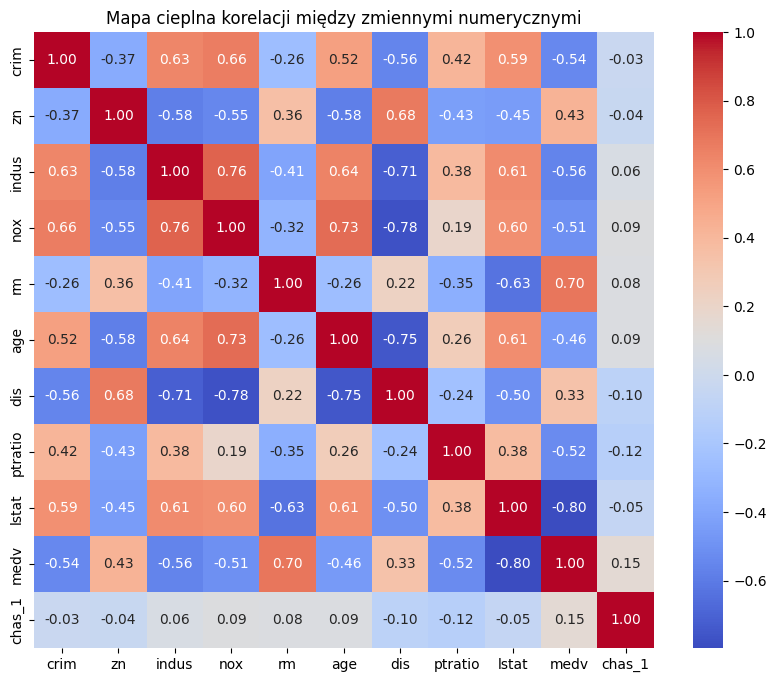

Korelacje względem medv:


,medv
medv,1.00
rm,0.70
zn,0.43
dis,0.33
chas_1,0.15
age,-0.46
nox,-0.51
ptratio,-0.52
crim,-0.54
indus,-0.56


In [33]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Mapa cieplna korelacji między zmiennymi numerycznymi")
plt.show()

print("Korelacje względem medv:")
display(corr['medv'].sort_values(ascending=False).round(2))

9. Zastosuj funkcję logarytmiczną i sigmoidalną na wybranych atrybutach numerycznych.

In [34]:
df['lstat_log'] = np.log1p(df['lstat'])
df['crim'] = np.log1p(df['crim'])

In [35]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

df['ptratio_sig'] = sigmoid(df['ptratio'])

In [36]:
from sklearn.model_selection import train_test_split

y = df['medv']
x = df.drop(columns=['medv'])

In [37]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [38]:
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=42
)

In [ ]:
# zbiór	procent
#train	70%
#val	15%
#test	15%

In [39]:
print(x_train.shape, x_val.shape, x_test.shape)
# sprawdzenie rozmiarów danych

(354, 12) (76, 12) (76, 12)


Dane zostały przygotowane do modelowania poprzez:

* identyfikację typów zmiennych (numeryczne i
kategoryczne),
* usunięcie kolumn z wartościami unikalnymi,
* brak konieczności uzupełniania braków danych,
* wykrycie wartości odstających metodą IQR i ich ograniczenie,
* zakodowanie zmiennej kategorycznej (chas),
* analizę korelacji i usunięcie silnie skorelowanych cech,
* zastosowanie transformacji logarytmicznej i sigmoidalnej,
* podział danych na zbiór treningowy, walidacyjny i testowy.

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [ ]:
df['chas'] = df['chas'].astype('category')

In [ ]:
(df.nunique() / len(df)).sort_values(ascending=False)

,0
Unnamed: 0,1.000000
crim,0.996047
lstat,0.899209
rm,0.881423
dis,0.814229
age,0.703557
medv,0.452569
nox,0.160079
indus,0.150198
tax,0.130435


In [ ]:
df.fillna(df.median(), inplace=True)

In [ ]:
for col in df.columns:
    if df[col].nunique() == len(df):
        df.drop(col, axis=1, inplace=True)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
corr_matrix = df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

df.drop(columns=to_drop, inplace=True)

In [ ]:
df['lstat_log'] = np.log1p(df['lstat'])

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

df['ptratio_sig'] = sigmoid(df['ptratio'])

In [ ]:
df['crim'] = np.log1p(df['crim'])

In [ ]:
from sklearn.model_selection import train_test_split

y = df['medv']
x = df.drop(columns=['medv'])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.25, random_state=42)